In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Number of customers
n = 1000

# --------------------------------------------------
# 1. CUSTOMER BASIC INFORMATION
# --------------------------------------------------

customer_id = [f"C{i:04d}" for i in range(1, n + 1)]

age = np.random.randint(21, 61, n)

gender = np.random.choice(
    ["Male", "Female"],
    size=n,
    p=[0.55, 0.45]
)

occupation = np.random.choice(
    ["Salaried", "Business", "Self-Employed", "Student"],
    size=n,
    p=[0.50, 0.25, 0.20, 0.05]
)

city = np.random.choice(
    ["Hyderabad", "Bangalore", "Mumbai",
     "Pune", "Chennai", "Delhi"],
    size=n
)


# --------------------------------------------------
# 2. MONTHLY INCOME
# --------------------------------------------------

income_ranges = {
    "Student": (10000, 30000),
    "Salaried": (30000, 150000),
    "Self-Employed": (35000, 180000),
    "Business": (50000, 250000)
}

monthly_income = np.array([
    np.random.randint(
        income_ranges[occ][0],
        income_ranges[occ][1] + 1
    )
    for occ in occupation
])


# --------------------------------------------------
# 3. ACCOUNT BALANCE
# --------------------------------------------------

# Balance is related to income
balance_multiplier = np.random.uniform(1.0, 5.0, n)

account_balance = (
    monthly_income * balance_multiplier
    + np.random.normal(0, 20000, n)
)

account_balance = np.maximum(
    account_balance,
    5000
).astype(int)


# --------------------------------------------------
# 4. CREDIT SCORE
# --------------------------------------------------

# Higher income generally contributes to slightly
# higher credit score, but with randomness

income_factor = (
    (monthly_income - monthly_income.min())
    / (monthly_income.max() - monthly_income.min())
)

credit_score = (
    650
    + income_factor * 120
    + np.random.normal(0, 30, n)
)

credit_score = np.clip(
    credit_score,
    550,
    850
).astype(int)


# --------------------------------------------------
# 5. MONTHLY TRANSACTIONS
# --------------------------------------------------

# Transaction activity related to income
transaction_base = (
    monthly_income / monthly_income.mean()
) * 40

monthly_transactions = (
    transaction_base
    + np.random.normal(0, 15, n)
)

monthly_transactions = np.clip(
    monthly_transactions,
    5,
    150
).astype(int)


# --------------------------------------------------
# 6. DIGITAL BANKING USAGE
# --------------------------------------------------

digital_score = (
    monthly_transactions
    + np.random.normal(0, 15, n)
)

digital_usage = np.where(
    digital_score >= 70,
    "High",
    np.where(
        digital_score >= 40,
        "Medium",
        "Low"
    )
)


# --------------------------------------------------
# 7. EXISTING LOAN
# --------------------------------------------------

loan_probability = (
    0.20
    + (monthly_income > 50000) * 0.20
    + (credit_score > 700) * 0.15
)

existing_loan = np.where(
    np.random.random(n) < loan_probability,
    "Yes",
    "No"
)


# --------------------------------------------------
# 8. CREDIT CARD
# --------------------------------------------------

credit_card_probability = (
    0.15
    + (monthly_income > 40000) * 0.20
    + (credit_score > 720) * 0.25
    + (monthly_transactions > 50) * 0.15
)

credit_card_probability = np.clip(
    credit_card_probability,
    0,
    0.90
)

credit_card = np.where(
    np.random.random(n) < credit_card_probability,
    "Yes",
    "No"
)


# --------------------------------------------------
# 9. INVESTMENT
# --------------------------------------------------

investment_probability = (
    0.10
    + (monthly_income > 70000) * 0.25
    + (account_balance > 200000) * 0.25
    + (age > 35) * 0.10
)

investment_probability = np.clip(
    investment_probability,
    0,
    0.85
)

investment = np.where(
    np.random.random(n) < investment_probability,
    "Yes",
    "No"
)


# --------------------------------------------------
# 10. INSURANCE
# --------------------------------------------------

insurance_probability = (
    0.15
    + (monthly_income > 50000) * 0.20
    + (age > 30) * 0.20
    + (existing_loan == "Yes") * 0.10
)

insurance_probability = np.clip(
    insurance_probability,
    0,
    0.85
)

insurance = np.where(
    np.random.random(n) < insurance_probability,
    "Yes",
    "No"
)


# --------------------------------------------------
# 11. CREATE DATAFRAME
# --------------------------------------------------

df = pd.DataFrame({
    "Customer_ID": customer_id,
    "Age": age,
    "Gender": gender,
    "Occupation": occupation,
    "Monthly_Income": monthly_income,
    "City": city,
    "Account_Balance": account_balance,
    "Credit_Score": credit_score,
    "Existing_Loan": existing_loan,
    "Credit_Card": credit_card,
    "Investment": investment,
    "Insurance": insurance,
    "Monthly_Transactions": monthly_transactions,
    "Digital_Usage": digital_usage
})


# --------------------------------------------------
# 12. DISPLAY DATA
# --------------------------------------------------

print("Dataset generated successfully!")
print(f"Number of customers: {len(df)}")
print(f"Number of columns: {len(df.columns)}")

display(df.head(10))

Dataset generated successfully!
Number of customers: 1000
Number of columns: 14


,Customer_ID,Age,Gender,Occupation,Monthly_Income,City,Account_Balance,Credit_Score,Existing_Loan,Credit_Card,Investment,Insurance,Monthly_Transactions,Digital_Usage
0,C0001,59,Male,Self-Employed,164744,Bangalore,342916,719,Yes,Yes,Yes,Yes,83,High
1,C0002,49,Female,Self-Employed,145684,Chennai,637230,711,Yes,No,No,Yes,47,Medium
2,C0003,35,Female,Salaried,89821,Bangalore,306942,710,Yes,No,No,No,25,Medium
3,C0004,28,Male,Salaried,116669,Delhi,379174,693,No,No,Yes,No,29,Low
4,C0005,41,Male,Business,225507,Pune,455957,780,Yes,Yes,Yes,No,95,High
5,C0006,59,Male,Self-Employed,170601,Delhi,656323,756,Yes,Yes,Yes,Yes,64,Medium
6,C0007,39,Male,Salaried,113055,Hyderabad,155250,681,No,No,Yes,No,14,Low
7,C0008,43,Female,Salaried,42192,Mumbai,189868,691,No,No,Yes,No,18,Low
8,C0009,31,Male,Salaried,104102,Hyderabad,244567,725,Yes,No,Yes,No,43,Low
9,C0010,31,Male,Business,164894,Mumbai,257164,674,Yes,Yes,Yes,No,59,Medium


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Customer_ID           1000 non-null   object
 1   Age                   1000 non-null   int64 
 2   Gender                1000 non-null   object
 3   Occupation            1000 non-null   object
 4   Monthly_Income        1000 non-null   int64 
 5   City                  1000 non-null   object
 6   Account_Balance       1000 non-null   int64 
 7   Credit_Score          1000 non-null   int64 
 8   Existing_Loan         1000 non-null   object
 9   Credit_Card           1000 non-null   object
 10  Investment            1000 non-null   object
 11  Insurance             1000 non-null   object
 12  Monthly_Transactions  1000 non-null   int64 
 13  Digital_Usage         1000 non-null   object
dtypes: int64(5), object(9)
memory usage: 109.5+ KB


In [ ]:
df.describe()

,Age,Monthly_Income,Account_Balance,Credit_Score,Monthly_Transactions
count,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000
mean,40.991000,106561.439000,3.136026e+05,698.973000,39.778000
std,11.780055,54165.433957,2.019783e+05,40.693171,24.064035
min,21.000000,10336.000000,5.000000e+03,568.000000,5.000000
25%,31.000000,63740.250000,1.576970e+05,672.000000,21.000000
50%,42.000000,103258.000000,2.656085e+05,697.000000,37.000000
75%,51.250000,139880.750000,4.297802e+05,725.000000,57.000000
max,60.000000,249298.000000,1.138693e+06,836.000000,119.000000


In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
Occupation,0
Monthly_Income,0
City,0
Account_Balance,0
Credit_Score,0
Existing_Loan,0
Credit_Card,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print("Occupation:")
print(df["Occupation"].value_counts())

print("\nCity:")
print(df["City"].value_counts())

print("\nExisting Loans:")
print(df["Existing_Loan"].value_counts())

print("\nCredit Cards:")
print(df["Credit_Card"].value_counts())

print("\nInvestments:")
print(df["Investment"].value_counts())

print("\nInsurance:")
print(df["Insurance"].value_counts())

Occupation:
Occupation
Salaried         486
Business         263
Self-Employed    202
Student           49
Name: count, dtype: int64

City:
City
Mumbai       186
Chennai      174
Hyderabad    174
Delhi        160
Bangalore    158
Pune         148
Name: count, dtype: int64

Existing Loans:
Existing_Loan
No     548
Yes    452
Name: count, dtype: int64

Credit Cards:
Credit_Card
No     557
Yes    443
Name: count, dtype: int64

Investments:
Investment
Yes    512
No     488
Name: count, dtype: int64

Insurance:
Insurance
Yes    512
No     488
Name: count, dtype: int64


In [ ]:
df.to_csv(
    "customer_360_banking.csv",
    index=False
)

print("Dataset saved as customer_360_banking.csv")

Dataset saved as customer_360_banking.csv


In [ ]:
from google.colab import files

files.download("customer_360_banking.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

df = pd.read_csv("customer_360_banking.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (1000, 14)


,Customer_ID,Age,Gender,Occupation,Monthly_Income,City,Account_Balance,Credit_Score,Existing_Loan,Credit_Card,Investment,Insurance,Monthly_Transactions,Digital_Usage
0,C0001,59,Male,Self-Employed,164744,Bangalore,342916,719,Yes,Yes,Yes,Yes,83,High
1,C0002,49,Female,Self-Employed,145684,Chennai,637230,711,Yes,No,No,Yes,47,Medium
2,C0003,35,Female,Salaried,89821,Bangalore,306942,710,Yes,No,No,No,25,Medium
3,C0004,28,Male,Salaried,116669,Delhi,379174,693,No,No,Yes,No,29,Low
4,C0005,41,Male,Business,225507,Pune,455957,780,Yes,Yes,Yes,No,95,High


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Customer_ID           1000 non-null   object
 1   Age                   1000 non-null   int64 
 2   Gender                1000 non-null   object
 3   Occupation            1000 non-null   object
 4   Monthly_Income        1000 non-null   int64 
 5   City                  1000 non-null   object
 6   Account_Balance       1000 non-null   int64 
 7   Credit_Score          1000 non-null   int64 
 8   Existing_Loan         1000 non-null   object
 9   Credit_Card           1000 non-null   object
 10  Investment            1000 non-null   object
 11  Insurance             1000 non-null   object
 12  Monthly_Transactions  1000 non-null   int64 
 13  Digital_Usage         1000 non-null   object
dtypes: int64(5), object(9)
memory usage: 109.5+ KB


In [ ]:
df.describe()

,Age,Monthly_Income,Account_Balance,Credit_Score,Monthly_Transactions
count,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000
mean,40.991000,106561.439000,3.136026e+05,698.973000,39.778000
std,11.780055,54165.433957,2.019783e+05,40.693171,24.064035
min,21.000000,10336.000000,5.000000e+03,568.000000,5.000000
25%,31.000000,63740.250000,1.576970e+05,672.000000,21.000000
50%,42.000000,103258.000000,2.656085e+05,697.000000,37.000000
75%,51.250000,139880.750000,4.297802e+05,725.000000,57.000000
max,60.000000,249298.000000,1.138693e+06,836.000000,119.000000


In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
Occupation,0
Monthly_Income,0
City,0
Account_Balance,0
Credit_Score,0
Existing_Loan,0
Credit_Card,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
categorical_columns = [
    "Gender",
    "Occupation",
    "City",
    "Existing_Loan",
    "Credit_Card",
    "Investment",
    "Insurance",
    "Digital_Usage"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Gender ---
Gender
Male      545
Female    455
Name: count, dtype: int64

--- Occupation ---
Occupation
Salaried         486
Business         263
Self-Employed    202
Student           49
Name: count, dtype: int64

--- City ---
City
Mumbai       186
Chennai      174
Hyderabad    174
Delhi        160
Bangalore    158
Pune         148
Name: count, dtype: int64

--- Existing_Loan ---
Existing_Loan
No     548
Yes    452
Name: count, dtype: int64

--- Credit_Card ---
Credit_Card
No     557
Yes    443
Name: count, dtype: int64

--- Investment ---
Investment
Yes    512
No     488
Name: count, dtype: int64

--- Insurance ---
Insurance
Yes    512
No     488
Name: count, dtype: int64

--- Digital_Usage ---
Digital_Usage
Low       508
Medium    340
High      152
Name: count, dtype: int64


In [ ]:
print("Minimum age:", df["Age"].min())
print("Maximum age:", df["Age"].max())

print("Minimum income:", df["Monthly_Income"].min())
print("Maximum income:", df["Monthly_Income"].max())

print("Minimum balance:", df["Account_Balance"].min())
print("Minimum credit score:", df["Credit_Score"].min())
print("Maximum credit score:", df["Credit_Score"].max())

print("Minimum transactions:", df["Monthly_Transactions"].min())
print("Maximum transactions:", df["Monthly_Transactions"].max())

Minimum age: 21
Maximum age: 60
Minimum income: 10336
Maximum income: 249298
Minimum balance: 5000
Minimum credit score: 568
Maximum credit score: 836
Minimum transactions: 5
Maximum transactions: 119


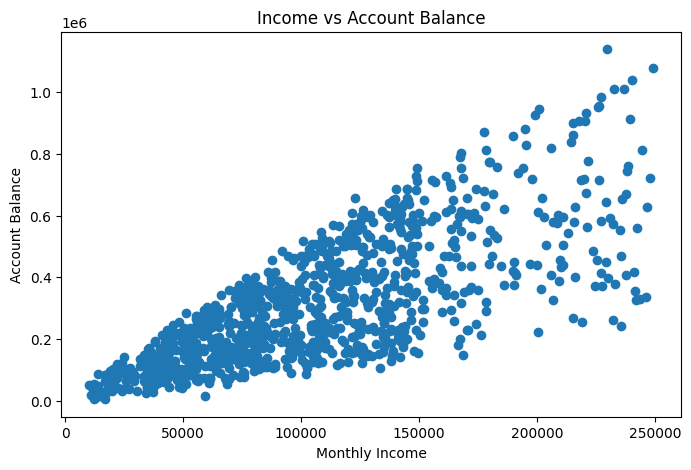

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df["Monthly_Income"], df["Account_Balance"])
plt.xlabel("Monthly Income")
plt.ylabel("Account Balance")
plt.title("Income vs Account Balance")
plt.show()

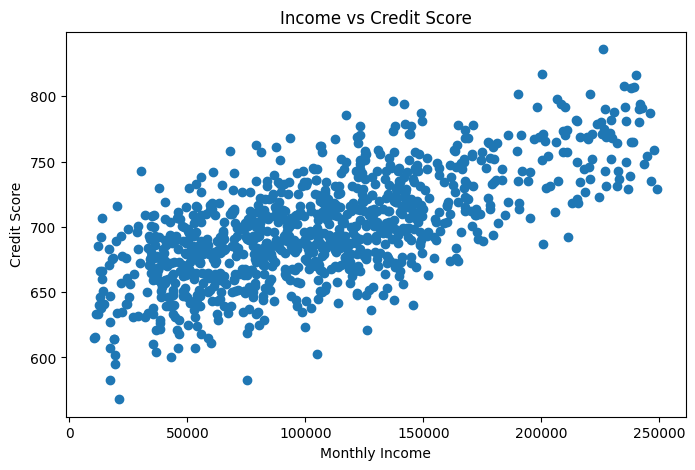

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Monthly_Income"], df["Credit_Score"])
plt.xlabel("Monthly Income")
plt.ylabel("Credit Score")
plt.title("Income vs Credit Score")
plt.show()

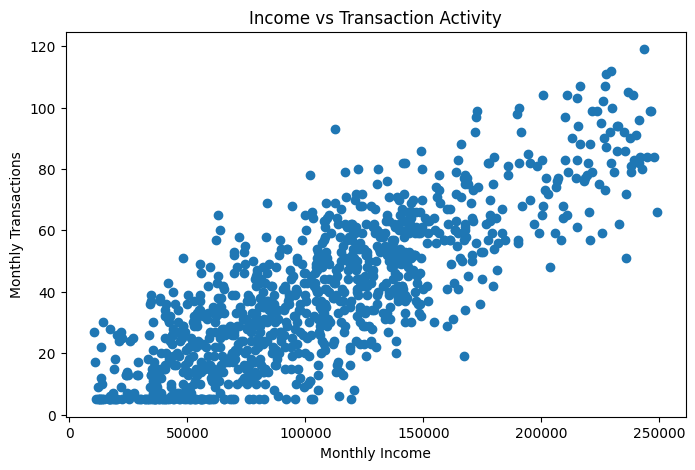

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Monthly_Income"], df["Monthly_Transactions"])
plt.xlabel("Monthly Income")
plt.ylabel("Monthly Transactions")
plt.title("Income vs Transaction Activity")
plt.show()

**Which customers have opportunities for deeper banking relationships?**

**1. Customer demographics**




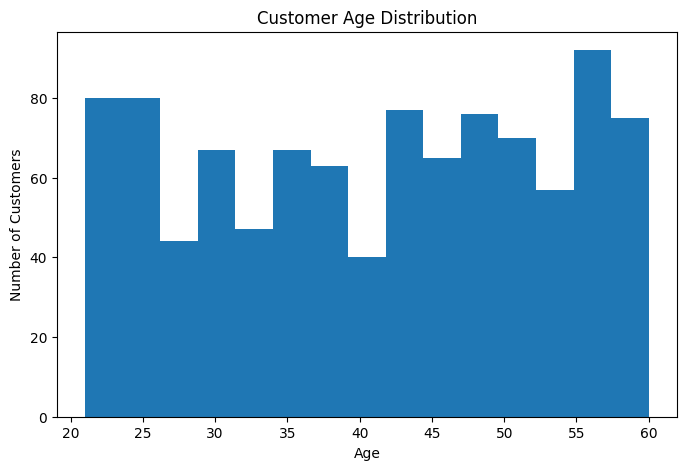

In [ ]:
import matplotlib.pyplot as plt

# Age distribution
plt.figure(figsize=(8, 5))
plt.hist(df["Age"], bins=15)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Customer Age Distribution")
plt.show()

**occupation**

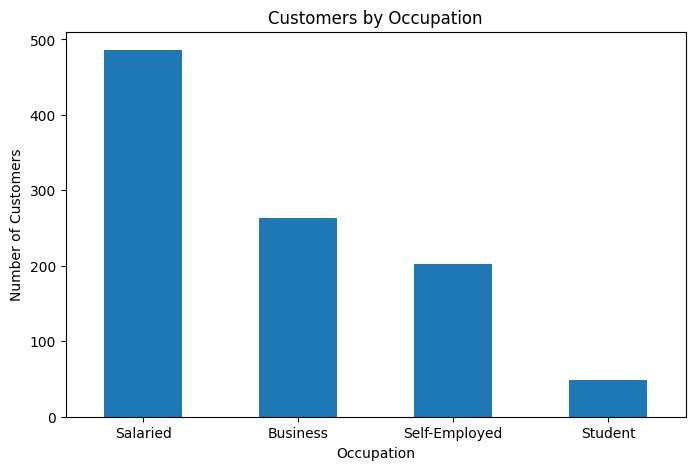

In [ ]:
occupation_counts = df["Occupation"].value_counts()

plt.figure(figsize=(8, 5))
occupation_counts.plot(kind="bar")
plt.xlabel("Occupation")
plt.ylabel("Number of Customers")
plt.title("Customers by Occupation")
plt.xticks(rotation=0)
plt.show()

**city**

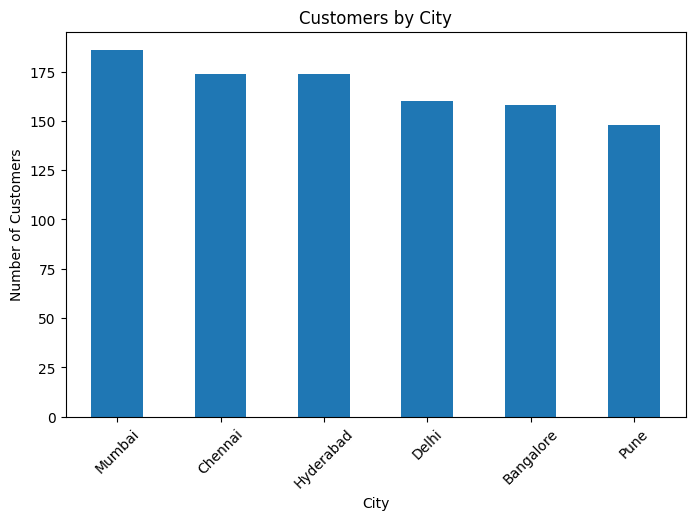

In [ ]:
city_counts = df["City"].value_counts()

plt.figure(figsize=(8, 5))
city_counts.plot(kind="bar")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.title("Customers by City")
plt.xticks(rotation=45)
plt.show()

**2. Financial profile**


**Income distribution**


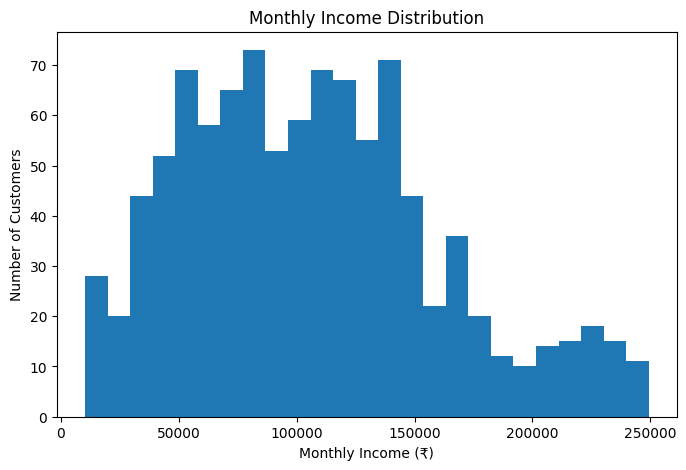

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["Monthly_Income"], bins=25)
plt.xlabel("Monthly Income (₹)")
plt.ylabel("Number of Customers")
plt.title("Monthly Income Distribution")
plt.show()

**Credit score**

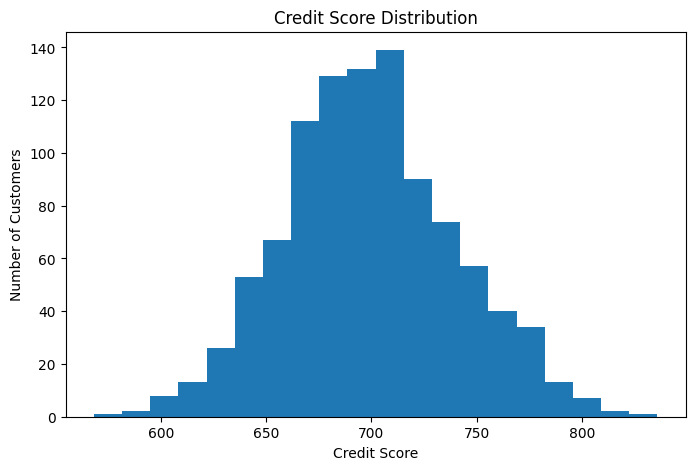

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["Credit_Score"], bins=20)
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")
plt.title("Credit Score Distribution")
plt.show()


**Account balance**

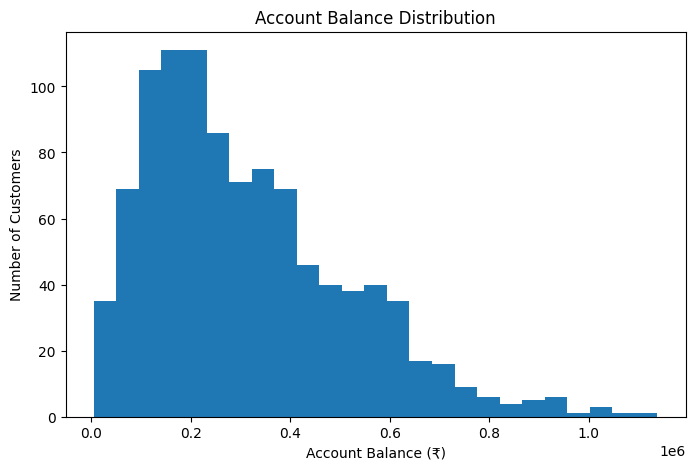

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["Account_Balance"], bins=25)
plt.xlabel("Account Balance (₹)")
plt.ylabel("Number of Customers")
plt.title("Account Balance Distribution")
plt.show()

**3. Banking product penetration**


Calculate how many customers have each product:


In [ ]:
products = [
    "Existing_Loan",
    "Credit_Card",
    "Investment",
    "Insurance"
]

product_counts = {}

for product in products:
    product_counts[product] = (
        df[product] == "Yes"
    ).sum()

product_counts

{'Existing_Loan': np.int64(452),
 'Credit_Card': np.int64(443),
 'Investment': np.int64(512),
 'Insurance': np.int64(512)}

Turn it into a DataFrame:


In [ ]:

product_summary = pd.DataFrame(
    list(product_counts.items()),
    columns=["Product", "Customers"]
)

product_summary




,Product,Customers
0,Existing_Loan,452
1,Credit_Card,443
2,Investment,512
3,Insurance,512


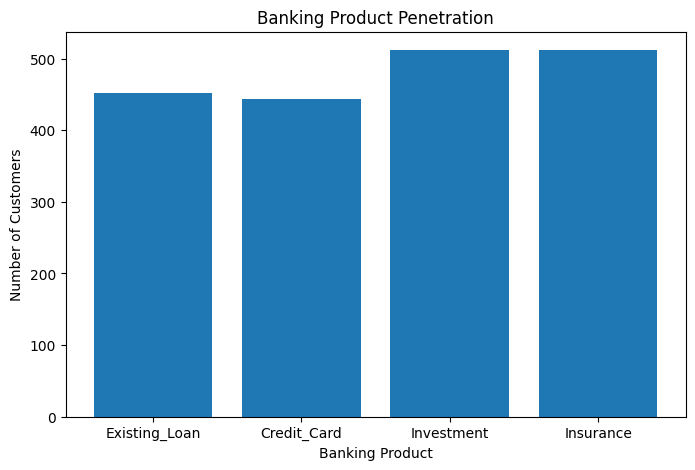

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    product_summary["Product"],
    product_summary["Customers"]
)

plt.xlabel("Banking Product")
plt.ylabel("Number of Customers")
plt.title("Banking Product Penetration")

plt.show()

**4. Create Product Count**

creating the first derived feature:


In [ ]:
products = [
    "Existing_Loan",
    "Credit_Card",
    "Investment",
    "Insurance"
]

df["Product_Count"] = (
    df[products] == "Yes"
).sum(axis=1)




In [ ]:
df[[
    "Customer_ID",
    "Existing_Loan",
    "Credit_Card",
    "Investment",
    "Insurance",
    "Product_Count"
]].head(10)

,Customer_ID,Existing_Loan,Credit_Card,Investment,Insurance,Product_Count
0,C0001,Yes,Yes,Yes,Yes,4
1,C0002,Yes,No,No,Yes,2
2,C0003,Yes,No,No,No,1
3,C0004,No,No,Yes,No,1
4,C0005,Yes,Yes,Yes,No,3
5,C0006,Yes,Yes,Yes,Yes,4
6,C0007,No,No,Yes,No,1
7,C0008,No,No,Yes,No,1
8,C0009,Yes,No,Yes,No,2
9,C0010,Yes,Yes,Yes,No,3


**5. Analyze Product Count**

In [ ]:
product_count_distribution = df["Product_Count"].value_counts().sort_index()

product_count_distribution




,count
Product_Count,
0,103
1,260
2,324
3,241
4,72


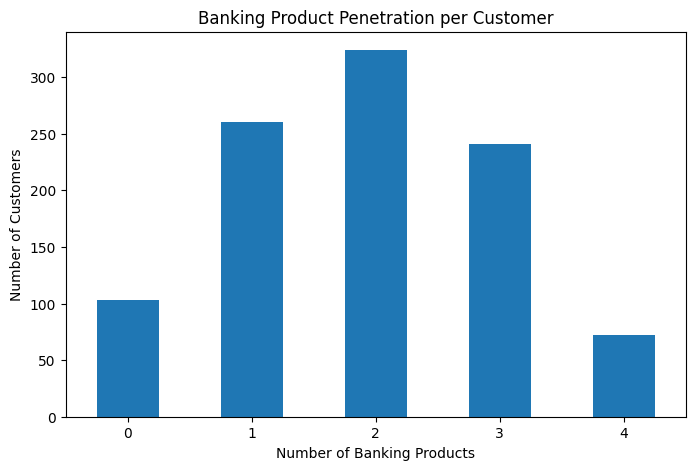

In [ ]:
plt.figure(figsize=(8, 5))

product_count_distribution.plot(kind="bar")

plt.xlabel("Number of Banking Products")
plt.ylabel("Number of Customers")
plt.title("Banking Product Penetration per Customer")
plt.xticks(rotation=0)

plt.show()

**6. Analyze customers with low product penetration**

This is going to become one of our key target populations.

Let's find customers who currently have 0 or 1 product:

In [ ]:
low_product_customers = df[
    df["Product_Count"] <= 1
]

print(
    "Customers with 0–1 banking products:",
    len(low_product_customers)
)

display(
    low_product_customers[
        [
            "Customer_ID",
            "Age",
            "Occupation",
            "Monthly_Income",
            "Account_Balance",
            "Credit_Score",
            "Product_Count"
        ]
    ].head(20)
)



Customers with 0–1 banking products: 363


,Customer_ID,Age,Occupation,Monthly_Income,Account_Balance,Credit_Score,Product_Count
2,C0003,35,Salaried,89821,306942,710,1
3,C0004,28,Salaried,116669,379174,693,1
6,C0007,39,Salaried,113055,155250,681,1
7,C0008,43,Salaried,42192,189868,691,1
11,C0012,56,Self-Employed,101677,121008,680,0
13,C0014,44,Student,24501,106531,641,0
16,C0017,22,Salaried,33255,65534,634,0
18,C0019,50,Salaried,35213,168097,638,0
19,C0020,58,Student,14108,15549,651,0
20,C0021,22,Salaried,49404,160269,715,1


**7. Find high-value customers with low product penetration**

Let's define a preliminary high-value customer as:


In [ ]:
high_value = df[
    (df["Monthly_Income"] >= 100000) &
    (df["Account_Balance"] >= 300000)
]

print("High-value customers:", len(high_value))




High-value customers: 367


Now find those with limited products:


Identifying customers with potentially strong relationship value but limited product penetration.

In [ ]:
high_value_low_penetration = high_value[
    high_value["Product_Count"] <= 1
]

print(
    "High-value customers with <=1 product:",
    len(high_value_low_penetration)
)

display(
    high_value_low_penetration[
        [
            "Customer_ID",
            "Occupation",
            "Monthly_Income",
            "Account_Balance",
            "Credit_Score",
            "Product_Count",
            "Credit_Card",
            "Investment",
            "Insurance",
            "Existing_Loan"
        ]
    ].head(20)
)

High-value customers with <=1 product: 81


,Customer_ID,Occupation,Monthly_Income,Account_Balance,Credit_Score,Product_Count,Credit_Card,Investment,Insurance,Existing_Loan
3,C0004,Salaried,116669,379174,693,1,No,Yes,No,No
34,C0035,Salaried,140887,572606,715,0,No,No,No,No
37,C0038,Salaried,128000,540025,713,0,No,No,No,No
43,C0044,Salaried,108653,306140,719,1,No,No,Yes,No
46,C0047,Salaried,121066,504685,666,0,No,No,No,No
66,C0067,Salaried,108768,499823,684,1,No,No,Yes,No
70,C0071,Self-Employed,126036,497191,690,1,No,Yes,No,No
87,C0088,Business,115149,334602,694,0,No,No,No,No
92,C0093,Business,164879,521057,778,1,No,Yes,No,No
95,C0096,Business,149165,540960,787,1,No,No,No,Yes


**8.Comparing average financial metrics by occupation.**

In [ ]:
occupation_analysis = df.groupby("Occupation").agg(
    Customers=("Customer_ID", "count"),
    Avg_Income=("Monthly_Income", "mean"),
    Avg_Balance=("Account_Balance", "mean"),
    Avg_Credit_Score=("Credit_Score", "mean"),
    Avg_Transactions=("Monthly_Transactions", "mean"),
    Avg_Products=("Product_Count", "mean")
).round(2)

occupation_analysis

,Customers,Avg_Income,Avg_Balance,Avg_Credit_Score,Avg_Transactions,Avg_Products
Occupation,,,,,,
Business,263,153379.35,445246.12,722.26,56.81,2.19
Salaried,486,90287.98,266409.82,690.95,33.27,1.85
Self-Employed,202,105906.03,317465.95,699.33,40.06,2.01
Student,49,19381.53,59175.31,652.06,11.76,0.73


**8. Product Gap Analysis**


In [ ]:
df["Credit_Card_Gap"] = np.where(
    df["Credit_Card"] == "No",
    "Potential Gap",
    "Already Owned"
)

df["Investment_Gap"] = np.where(
    df["Investment"] == "No",
    "Potential Gap",
    "Already Owned"
)

df["Insurance_Gap"] = np.where(
    df["Insurance"] == "No",
    "Potential Gap",
    "Already Owned"
)

df["Loan_Gap"] = np.where(
    df["Existing_Loan"] == "No",
    "Potential Gap",
    "Already Owned"
)

# Display results
display(
    df[
        [
            "Customer_ID",
            "Monthly_Income",
            "Credit_Score",
            "Account_Balance",
            "Credit_Card",
            "Credit_Card_Gap",
            "Investment",
            "Investment_Gap",
            "Insurance",
            "Insurance_Gap",
            "Existing_Loan",
            "Loan_Gap"
        ]
    ].head(10)
)

,Customer_ID,Monthly_Income,Credit_Score,Account_Balance,Credit_Card,Credit_Card_Gap,Investment,Investment_Gap,Insurance,Insurance_Gap,Existing_Loan,Loan_Gap
0,C0001,164744,719,342916,Yes,Already Owned,Yes,Already Owned,Yes,Already Owned,Yes,Already Owned
1,C0002,145684,711,637230,No,Potential Gap,No,Potential Gap,Yes,Already Owned,Yes,Already Owned
2,C0003,89821,710,306942,No,Potential Gap,No,Potential Gap,No,Potential Gap,Yes,Already Owned
3,C0004,116669,693,379174,No,Potential Gap,Yes,Already Owned,No,Potential Gap,No,Potential Gap
4,C0005,225507,780,455957,Yes,Already Owned,Yes,Already Owned,No,Potential Gap,Yes,Already Owned
5,C0006,170601,756,656323,Yes,Already Owned,Yes,Already Owned,Yes,Already Owned,Yes,Already Owned
6,C0007,113055,681,155250,No,Potential Gap,Yes,Already Owned,No,Potential Gap,No,Potential Gap
7,C0008,42192,691,189868,No,Potential Gap,Yes,Already Owned,No,Potential Gap,No,Potential Gap
8,C0009,104102,725,244567,No,Potential Gap,Yes,Already Owned,No,Potential Gap,Yes,Already Owned
9,C0010,164894,674,257164,Yes,Already Owned,Yes,Already Owned,No,Potential Gap,Yes,Already Owned


**Step 9 — Identify potential Credit Card customers**

Let's start with one product.

A potential credit-card opportunity could be someone who:

*   Has no credit card

*   Has reasonable income

*   Has a good credit score

*   Has reasonably active transactions









In [ ]:
df["Credit_Card_Opportunity"] = np.where(
    (df["Credit_Card"] == "No") &
    (df["Monthly_Income"] >= 40000) &
    (df["Credit_Score"] >= 700) &
    (df["Monthly_Transactions"] >= 40),
    "High",
    "Low"
)

print(
    "Potential Credit Card Opportunities:",
    (df["Credit_Card_Opportunity"] == "High").sum()
)

Potential Credit Card Opportunities: 109


In [ ]:
credit_card_opportunities = df[
    df["Credit_Card_Opportunity"] == "High"
]

display(
    credit_card_opportunities[
        [
            "Customer_ID",
            "Age",
            "Occupation",
            "Monthly_Income",
            "Credit_Score",
            "Monthly_Transactions",
            "Credit_Card"
        ]
    ].head(20)
)

,Customer_ID,Age,Occupation,Monthly_Income,Credit_Score,Monthly_Transactions,Credit_Card
1,C0002,49,Self-Employed,145684,711,47,No
8,C0009,31,Salaried,104102,725,43,No
34,C0035,29,Salaried,140887,715,42,No
41,C0042,46,Business,227295,769,87,No
89,C0090,55,Business,235639,792,86,No
92,C0093,59,Business,164879,778,41,No
105,C0106,42,Salaried,134383,703,63,No
109,C0110,55,Business,127694,708,68,No
128,C0129,50,Salaried,115103,752,50,No
147,C0148,48,Self-Employed,122438,738,54,No


**10. Investment opportunity**

Now identify customers who may have investment potential.

We'll look for:

*   No existing investment
*   Higher income
*   Higher account balance
*   Reasonable age

In [ ]:
df["Investment_Opportunity"] = np.where(
    (df["Investment"] == "No") &
    (df["Monthly_Income"] >= 70000) &
    (df["Account_Balance"] >= 200000) &
    (df["Age"] >= 30),
    "High",
    "Low"
)

print(
    "Potential Investment Opportunities:",
    (df["Investment_Opportunity"] == "High").sum()
)

Potential Investment Opportunities: 125


In [ ]:
investment_opportunities = df[
    df["Investment_Opportunity"] == "High"
]

display(
    investment_opportunities[
        [
            "Customer_ID",
            "Age",
            "Occupation",
            "Monthly_Income",
            "Account_Balance",
            "Credit_Score",
            "Investment"
        ]
    ].head(20)
)

,Customer_ID,Age,Occupation,Monthly_Income,Account_Balance,Credit_Score,Investment
1,C0002,49,Self-Employed,145684,637230,711,No
2,C0003,35,Salaried,89821,306942,710,No
23,C0024,32,Salaried,121056,410563,701,No
25,C0026,45,Salaried,83027,206489,707,No
33,C0034,41,Business,73559,316961,635,No
36,C0037,38,Business,186093,621201,719,No
41,C0042,46,Business,227295,414534,769,No
43,C0044,40,Salaried,108653,306140,719,No
47,C0048,55,Self-Employed,94546,469764,668,No
66,C0067,34,Salaried,108768,499823,684,No


**11. Insurance opportunity**

For insurance, we'll consider:

* No insurance
* Income above ₹50K
* Age above 30
* loan as an additional signal

In [ ]:
df["Insurance_Opportunity"] = np.where(
    (df["Insurance"] == "No") &
    (df["Monthly_Income"] >= 50000) &
    (df["Age"] >= 30),
    "High",
    "Low"
)

print(
    "Potential Insurance Opportunities:",
    (df["Insurance_Opportunity"] == "High").sum()
)

Potential Insurance Opportunities: 279


**12. Loan opportunity**

For loans, Potential indicators:
* No existing loan
* Income ≥ ₹50K
* Credit score ≥ 720
* Active customer

In [ ]:

df["Loan_Opportunity"] = np.where(
    (df["Existing_Loan"] == "No") &
    (df["Monthly_Income"] >= 50000) &
    (df["Credit_Score"] >= 720) &
    (df["Monthly_Transactions"] >= 30),
    "High",
    "Low"
)

print(
    "Potential Loan Opportunities:",
    (df["Loan_Opportunity"] == "High").sum()
)

Potential Loan Opportunities: 105


**13. See all opportunities together**

Now create a summary:


In [ ]:

opportunity_summary = pd.DataFrame({
    "Product": [
        "Credit Card",
        "Investment",
        "Insurance",
        "Loan"
    ],
    "Potential_Opportunities": [
        (df["Credit_Card_Opportunity"] == "High").sum(),
        (df["Investment_Opportunity"] == "High").sum(),
        (df["Insurance_Opportunity"] == "High").sum(),
        (df["Loan_Opportunity"] == "High").sum()
    ]
})

display(opportunity_summary)

,Product,Potential_Opportunities
0,Credit Card,109
1,Investment,125
2,Insurance,279
3,Loan,105


**14.Next Best Product**

Right now, a customer can have multiple opportunities:

Customer C001
 * Credit Card → High
 * Investment → Low
 * Insurance → High
 * Loan → Low

But a Relationship Manager needs a clear answer:

Which opportunity should I prioritize for this customer?

So we'll create a Next Best Product.

**14.1 Create the recommendation logic**



In [ ]:


def get_next_best_product(row):

    opportunities = {
        "Credit Card": row["Credit_Card_Opportunity"],
        "Investment": row["Investment_Opportunity"],
        "Insurance": row["Insurance_Opportunity"],
        "Loan": row["Loan_Opportunity"]
    }

    # Priority order
    priority = [
        "Investment",
        "Credit Card",
        "Insurance",
        "Loan"
    ]

    for product in priority:
        if opportunities[product] == "High":
            return product

    return "No Immediate Opportunity"


df["Next_Best_Product"] = df.apply(
    get_next_best_product,
    axis=1
)

display(
    df[
        [
            "Customer_ID",
            "Monthly_Income",
            "Account_Balance",
            "Credit_Score",
            "Product_Count",
            "Next_Best_Product"
        ]
    ].head(20)
)

,Customer_ID,Monthly_Income,Account_Balance,Credit_Score,Product_Count,Next_Best_Product
0,C0001,164744,342916,719,4,No Immediate Opportunity
1,C0002,145684,637230,711,2,Investment
2,C0003,89821,306942,710,1,Investment
3,C0004,116669,379174,693,1,No Immediate Opportunity
4,C0005,225507,455957,780,3,Insurance
5,C0006,170601,656323,756,4,No Immediate Opportunity
6,C0007,113055,155250,681,1,Insurance
7,C0008,42192,189868,691,1,No Immediate Opportunity
8,C0009,104102,244567,725,2,Credit Card
9,C0010,164894,257164,674,3,Insurance


**14.2 See your recommendations**

In [ ]:
recommendation_summary = (
    df["Next_Best_Product"]
    .value_counts()
    .reset_index()
)

recommendation_summary.columns = [
    "Recommended_Product",
    "Customers"
]

display(recommendation_summary)

,Recommended_Product,Customers
0,No Immediate Opportunity,543
1,Insurance,202
2,Investment,125
3,Credit Card,87
4,Loan,43


**14.3 Visualize it**

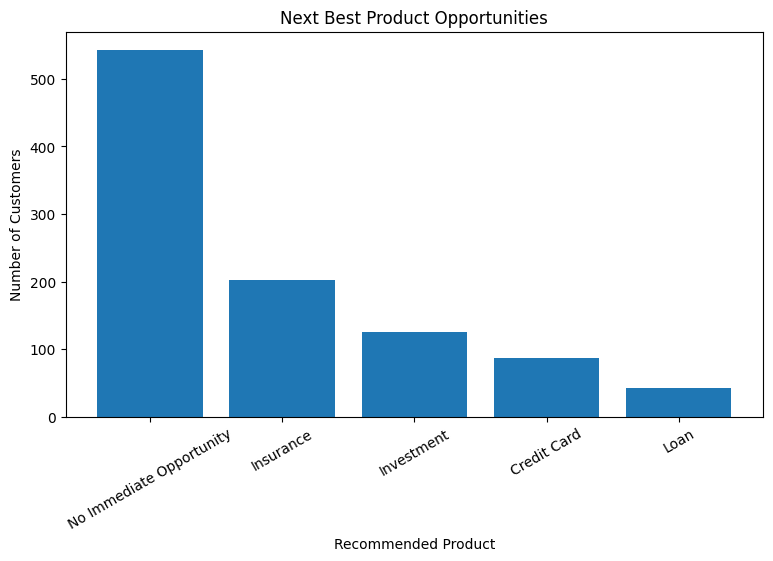

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    recommendation_summary["Recommended_Product"],
    recommendation_summary["Customers"]
)

plt.xlabel("Recommended Product")
plt.ylabel("Number of Customers")
plt.title("Next Best Product Opportunities")

plt.xticks(rotation=30)

plt.show()

**15. Create Opportunity Score**

In [ ]:


df["Credit_Card_Score"] = (
    (df["Credit_Card"] == "No") * 30 +
    (df["Monthly_Income"] >= 40000) * 25 +
    (df["Credit_Score"] >= 700) * 25 +
    (df["Monthly_Transactions"] >= 40) * 20
)

df["Credit_Card_Score"] = df["Credit_Card_Score"].astype(int)

In [ ]:
display(
    df[
        [
            "Customer_ID",
            "Credit_Card",
            "Monthly_Income",
            "Credit_Score",
            "Monthly_Transactions",
            "Credit_Card_Score"
        ]
    ].head(20)
)

,Customer_ID,Credit_Card,Monthly_Income,Credit_Score,Monthly_Transactions,Credit_Card_Score
0,C0001,Yes,164744,719,83,70
1,C0002,No,145684,711,47,100
2,C0003,No,89821,710,25,80
3,C0004,No,116669,693,29,55
4,C0005,Yes,225507,780,95,70
5,C0006,Yes,170601,756,64,70
6,C0007,No,113055,681,14,55
7,C0008,No,42192,691,18,55
8,C0009,No,104102,725,43,100
9,C0010,Yes,164894,674,59,45


**16. Investment Score**

In [ ]:

df["Investment_Score"] = (
    (df["Investment"] == "No") * 30 +
    (df["Monthly_Income"] >= 70000) * 25 +
    (df["Account_Balance"] >= 200000) * 25 +
    (df["Age"] >= 30) * 20
)

df["Investment_Score"] = df["Investment_Score"].astype(int)

**17. Insurance Score**

In [ ]:

df["Insurance_Score"] = (
    (df["Insurance"] == "No") * 30 +
    (df["Monthly_Income"] >= 50000) * 25 +
    (df["Age"] >= 30) * 25 +
    (df["Existing_Loan"] == "Yes") * 20
)

df["Insurance_Score"] = df["Insurance_Score"].astype(int)

**18. Loan Score**

In [ ]:

df["Loan_Score"] = (
    (df["Existing_Loan"] == "No") * 30 +
    (df["Monthly_Income"] >= 50000) * 25 +
    (df["Credit_Score"] >= 720) * 25 +
    (df["Monthly_Transactions"] >= 30) * 20
)

df["Loan_Score"] = df["Loan_Score"].astype(int)

**Step 19 — Find the highest opportunity**

Now we'll compare all four scores for each customer.

In [ ]:


score_columns = [
    "Credit_Card_Score",
    "Investment_Score",
    "Insurance_Score",
    "Loan_Score"
]

df["Max_Opportunity_Score"] = df[score_columns].max(axis=1)

display(
    df[
        [
            "Customer_ID",
            "Credit_Card_Score",
            "Investment_Score",
            "Insurance_Score",
            "Loan_Score",
            "Max_Opportunity_Score"
        ]
    ].head(20)
)

,Customer_ID,Credit_Card_Score,Investment_Score,Insurance_Score,Loan_Score,Max_Opportunity_Score
0,C0001,70,70,70,45,70
1,C0002,100,100,70,45,100
2,C0003,80,100,100,25,100
3,C0004,55,50,55,55,55
4,C0005,70,70,100,70,100
5,C0006,70,70,70,70,70
6,C0007,55,45,80,55,80
7,C0008,55,20,55,30,55
8,C0009,100,70,100,70,100
9,C0010,45,70,100,45,100


**20. Update Next Best Product using the highest score**

Now instead of our arbitrary priority order, we can use the highest opportunity score.

In [ ]:


def get_best_product(row):

    scores = {
        "Credit Card": row["Credit_Card_Score"],
        "Investment": row["Investment_Score"],
        "Insurance": row["Insurance_Score"],
        "Loan": row["Loan_Score"]
    }

    best_product = max(
        scores,
        key=scores.get
    )

    best_score = scores[best_product]

    if best_score < 50:
        return "No Immediate Opportunity"

    return best_product


df["Next_Best_Product"] = df.apply(
    get_best_product,
    axis=1
)




In [ ]:
display(
    df[
        [
            "Customer_ID",
            "Credit_Card_Score",
            "Investment_Score",
            "Insurance_Score",
            "Loan_Score",
            "Max_Opportunity_Score",
            "Next_Best_Product"
        ]
    ].head(20)
)

,Customer_ID,Credit_Card_Score,Investment_Score,Insurance_Score,Loan_Score,Max_Opportunity_Score,Next_Best_Product
0,C0001,70,70,70,45,70,Credit Card
1,C0002,100,100,70,45,100,Credit Card
2,C0003,80,100,100,25,100,Investment
3,C0004,55,50,55,55,55,Credit Card
4,C0005,70,70,100,70,100,Insurance
5,C0006,70,70,70,70,70,Credit Card
6,C0007,55,45,80,55,80,Insurance
7,C0008,55,20,55,30,55,Credit Card
8,C0009,100,70,100,70,100,Credit Card
9,C0010,45,70,100,45,100,Insurance


**21. Prepare the final dataset for Power BI**



In [ ]:
final_columns = [
    "Customer_ID",
    "Age",
    "Gender",
    "Occupation",
    "Monthly_Income",
    "City",
    "Account_Balance",
    "Credit_Score",
    "Existing_Loan",
    "Credit_Card",
    "Investment",
    "Insurance",
    "Monthly_Transactions",
    "Digital_Usage",
    "Product_Count",
    "Credit_Card_Score",
    "Investment_Score",
    "Insurance_Score",
    "Loan_Score",
    "Max_Opportunity_Score",
    "Next_Best_Product"
]

final_df = df[final_columns].copy()

print("Final dataset shape:", final_df.shape)

display(final_df.head())

Final dataset shape: (1000, 21)


,Customer_ID,Age,Gender,Occupation,Monthly_Income,City,Account_Balance,Credit_Score,Existing_Loan,Credit_Card,...,Insurance,Monthly_Transactions,Digital_Usage,Product_Count,Credit_Card_Score,Investment_Score,Insurance_Score,Loan_Score,Max_Opportunity_Score,Next_Best_Product
0,C0001,59,Male,Self-Employed,164744,Bangalore,342916,719,Yes,Yes,...,Yes,83,High,4,70,70,70,45,70,Credit Card
1,C0002,49,Female,Self-Employed,145684,Chennai,637230,711,Yes,No,...,Yes,47,Medium,2,100,100,70,45,100,Credit Card
2,C0003,35,Female,Salaried,89821,Bangalore,306942,710,Yes,No,...,No,25,Medium,1,80,100,100,25,100,Investment
3,C0004,28,Male,Salaried,116669,Delhi,379174,693,No,No,...,No,29,Low,1,55,50,55,55,55,Credit Card
4,C0005,41,Male,Business,225507,Pune,455957,780,Yes,Yes,...,No,95,High,3,70,70,100,70,100,Insurance


**22. Add Opportunity Level**

Let's create an easy-to-understand business category.




In [ ]:

def opportunity_level(score):

    if score >= 80:
        return "High"

    elif score >= 50:
        return "Medium"

    else:
        return "Low"


final_df["Opportunity_Level"] = (
    final_df["Max_Opportunity_Score"]
    .apply(opportunity_level)
)

display(
    final_df[
        [
            "Customer_ID",
            "Max_Opportunity_Score",
            "Opportunity_Level",
            "Next_Best_Product"
        ]
    ].head(20)
)

,Customer_ID,Max_Opportunity_Score,Opportunity_Level,Next_Best_Product
0,C0001,70,Medium,Credit Card
1,C0002,100,High,Credit Card
2,C0003,100,High,Investment
3,C0004,55,Medium,Credit Card
4,C0005,100,High,Insurance
5,C0006,70,Medium,Credit Card
6,C0007,80,High,Insurance
7,C0008,55,Medium,Credit Card
8,C0009,100,High,Credit Card
9,C0010,100,High,Insurance


**23. Add Customer Value**

We also want the Relationship Manager to understand the customer's overall value.

We'll use a simple transparent rule.

In [ ]:
def customer_value(row):

    if (
        row["Monthly_Income"] >= 100000
        and row["Account_Balance"] >= 300000
    ):
        return "High Value"

    elif (
        row["Monthly_Income"] >= 50000
        or row["Account_Balance"] >= 150000
    ):
        return "Medium Value"

    else:
        return "Emerging"


final_df["Customer_Value"] = final_df.apply(
    customer_value,
    axis=1
)

display(
    final_df[
        [
            "Customer_ID",
            "Monthly_Income",
            "Account_Balance",
            "Customer_Value"
        ]
    ].head(20)
)

,Customer_ID,Monthly_Income,Account_Balance,Customer_Value
0,C0001,164744,342916,High Value
1,C0002,145684,637230,High Value
2,C0003,89821,306942,Medium Value
3,C0004,116669,379174,High Value
4,C0005,225507,455957,High Value
5,C0006,170601,656323,High Value
6,C0007,113055,155250,Medium Value
7,C0008,42192,189868,Medium Value
8,C0009,104102,244567,Medium Value
9,C0010,164894,257164,Medium Value


**24. The final Power BI dataset**


In [ ]:
final_df.to_csv(
    "customer_360_powerbi.csv",
    index=False
)

print("Power BI dataset created successfully!")
print("Rows:", len(final_df))
print("Columns:", len(final_df.columns))




Power BI dataset created successfully!
Rows: 1000
Columns: 23


In [ ]:
from google.colab import files

files.download("customer_360_powerbi.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Customer_ID            1000 non-null   object
 1   Age                    1000 non-null   int64 
 2   Gender                 1000 non-null   object
 3   Occupation             1000 non-null   object
 4   Monthly_Income         1000 non-null   int64 
 5   City                   1000 non-null   object
 6   Account_Balance        1000 non-null   int64 
 7   Credit_Score           1000 non-null   int64 
 8   Existing_Loan          1000 non-null   object
 9   Credit_Card            1000 non-null   object
 10  Investment             1000 non-null   object
 11  Insurance              1000 non-null   object
 12  Monthly_Transactions   1000 non-null   int64 
 13  Digital_Usage          1000 non-null   object
 14  Product_Count          1000 non-null   int64 
 15  Credit_Card_Score     

In [ ]:
final_df.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
Occupation,0
Monthly_Income,0
City,0
Account_Balance,0
Credit_Score,0
Existing_Loan,0
Credit_Card,0


**25. Export the final dataset**

In [ ]:

final_df.to_csv(
    "customer_360_powerbi.csv",
    index=False
)

print("Saved successfully!")
print("Rows:", final_df.shape[0])
print("Columns:", final_df.shape[1])


Saved successfully!
Rows: 1000
Columns: 23


In [ ]:
from google.colab import files

files.download("customer_360_powerbi.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>